# Introdução ao LangGraph

LangGraph é um framework para criar aplicações usando fluxos de trabalho baseados em grafos. Cada nó representa uma função ou etapa computacional, e as arestas definem o fluxo entre esses nós com base em certas condições.

## Características principais:
- Gerenciamento de estado
- Roteamento flexível
- Persistência
- Visualização

## Visão Geral do Tutorial: Pipeline de Análise de Texto

Neste tutorial, demonstraremos o poder do LangGraph construindo um pipeline de análise de texto em várias etapas. Nosso caso de uso se concentrará no processamento de um determinado texto através de três estágios principais:

1. **Classificação de Texto**: Categorizaremos o texto de entrada em categorias predefinidas (por exemplo, Notícias, Blog, Pesquisa ou Outro).
2. **Extração de Entidades**: Identificaremos e extrairemos entidades-chave como pessoas, organizações e locais do texto.
3. **Resumo de Texto**: Por fim, geraremos um resumo conciso do texto de entrada.

Este pipeline demonstra como o LangGraph pode ser usado para criar um fluxo de trabalho modular e extensível para tarefas de processamento de linguagem natural. Ao final deste tutorial, você entenderá como construir uma aplicação baseada em grafos que pode ser facilmente modificada ou expandida para várias necessidades de análise de texto.

### Importar Bibliotecas Necessárias
Esta célula importa todos os módulos e classes necessários para nosso tutorial do LangGraph.

In [1]:
import sys
print(sys.executable)

c:\Users\jpsel\OneDrive\Documentos\projetos\genAI-projects\genAI-text-summarizer\.venv\Scripts\python.exe


In [21]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

from dotenv import load_dotenv

# Importações para manipulação de sistema e tipos
# Importações do LangGraph para criação do grafo de estado
# Importações do LangChain para prompts, modelos de linguagem e mensagens
# Importação para visualização do grafo
# Importações para exibição no Jupyter
# Importação para carregar variáveis de ambiente

In [3]:
# Carrega as variáveis do arquivo .env diretamente para o os.environ
load_dotenv()
# Verifica se a chave foi carregada corretamente
if not os.getenv("GEMINI_API_KEY"):
    print("Aviso: GEMINI_API_KEY não encontrada! Certifique-se de preencher o arquivo .env.")
else:
    print("Chave do Gemini carregada com sucesso!")

Chave do Gemini carregada com sucesso!


## Construindo o Pipeline de Processamento de Texto

### Definir Estado e Inicializar LLM
Aqui definimos a classe State para armazenar os dados do nosso fluxo de trabalho e inicializamos o modelo Gemini.

In [ ]:
class State(TypedDict):
    text: str
    classification: str
    entities: List[str]
    summary: str

llm = ChatGoogleGenerativeAI(
    model='gemini-3.1-flash-lite', 
    temperature=0
    )

### Definir Funções dos Nós
Estas funções definem as operações realizadas em cada nó do nosso grafo: classificação, extração de entidades e resumo.

In [45]:
def classification_node(state: State):
    ''' Classifica o texto em uma das categorias: Notícias, Blog, Pesquisa ou Outro '''
    prompt = PromptTemplate(
        input_variables=["text"],
        template="""Classifique o seguinte texto em uma das categorias: 
            Notícias, Blog, Pesquisa, Comentário ou Outro.\n\nTexto:{text}\n\nCategoria:
            """
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    classification = llm.invoke([message]).content[0]['text']
    return {"classification": classification}


def entity_extraction_node(state: State):
    ''' Extrai todas as entidades (Pessoa, Organização, Local) do texto '''
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Extraia todas as entidades (Pessoa, Organização, Local) do seguinte texto. Forneça o resultado como uma lista separada por vírgulas.\n\nTexto:{text}\n\nEntidades:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    entities = llm.invoke([message]).content[0]['text']
    return {"entities": entities}


def summarization_node(state: State):
    ''' Resume o texto em uma frase curta '''
    prompt = PromptTemplate(
        input_variables=["text"],
        template="Resuma o seguinte texto em uma frase curta.\n\nTexto:{text}\n\nResumo:"
    )
    message = HumanMessage(content=prompt.format(text=state["text"]))
    summary = llm.invoke([message]).content[0]['text']
    return {"summary": summary}

### Criar Ferramentas e Construir Fluxo de Trabalho
Esta célula constrói o fluxo de trabalho StateGraph.

In [46]:
workflow = StateGraph(State)

# Adicionar nós ao grafo
workflow.add_node("classification_node", classification_node)
workflow.add_node("entity_extraction", entity_extraction_node)
workflow.add_node("summarization", summarization_node)

# Adicionar arestas ao grafo
workflow.set_entry_point("classification_node") # Definir o ponto de entrada do grafo
workflow.add_edge("classification_node", "entity_extraction")
workflow.add_edge("entity_extraction", "summarization")
workflow.add_edge("summarization", END)

# Compilar o grafo
app = workflow.compile()

In [47]:
workflow = StateGraph(State)

# Adicionar nós ao grafo
workflow.add_node("classification_node", classification_node)
workflow.add_node("entity_extraction", entity_extraction_node)
workflow.add_node("summarization", summarization_node)

workflow.add_edge(START, "classification_node")
workflow.add_edge(START, "entity_extraction")
workflow.add_edge(START, "summarization")

workflow.add_edge("classification_node", END)
workflow.add_edge("entity_extraction", END)
workflow.add_edge("summarization", END)

# Compilar o grafo
app = workflow.compile()

## Visualizando o Fluxo de Trabalho
Esta célula cria uma representação visual do nosso fluxo de trabalho usando Mermaid

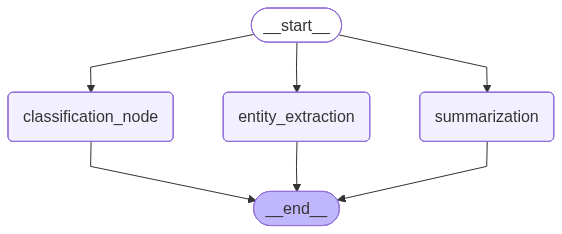

In [48]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Testando o Pipeline
Esta célula executa um texto de exemplo através do nosso pipeline e exibe os resultados.

In [51]:
sample_text = """
A Fifa tem um prêmio Golden Boot (chuteira de ouro) para o artilheiro da Copa. Quem lidera ao final da primeira fase é o argentino Lionel Messi, com seis gols.

O Brasil, que tem o maior número de vencedores na história, tem um concorrente em Vinícius Jr. Ele está com quatro gols.

O brasileiro está em quarto na lista, atrás de Mbappé e Dembelé, que têm o mesmo número de gols do brasileiro. Há uma explicação: a Fifa tem dois critérios de desempate para o prêmio.

"""

state_input = {"text": sample_text}
result = app.invoke(state_input)

print("Classificação:", result["classification"])
print("\nEntidades:", result["entities"])
print("\nResumo:", result["summary"])

Classificação: Categoria: Notícias

Entidades: Entidades: Fifa, Lionel Messi, Brasil, Vinícius Jr., Mbappé, Dembelé

Resumo: Resumo: Lionel Messi lidera a disputa pela Chuteira de Ouro da Copa, com Vinícius Jr. entre os concorrentes brasileiros.
